[Previous: Module 4: Measurement & Interference](04_Measurement_and_Interference.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 6: Deutsch-Jozsa, the First Quantum Speed-up](06_Deutsch_Jozsa_Algorithm.ipynb)

# Module 5: Quantum Teleportation

**Learning objectives.** After this module you can:

* state the no-cloning theorem and explain why it makes "just copy the qubit" impossible;
* walk through the five steps of the teleportation protocol and say what each qubit and each classical bit is for;
* implement the protocol two ways: as a pure unitary circuit (deferred measurement) and as the real thing with mid-circuit measurement and classical feed-forward;
* *prove* Bob received the state, using fidelity and a verification measurement.

**Prerequisites.** [Module 3](03_Multiple_Qubits_and_Entanglement.ipynb) (Bell states) and [Module 4](04_Measurement_and_Interference.ipynb) (measurement bases).

## 1. The problem, and why the obvious solutions fail

Alice holds a qubit in some state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$. She does not know $\alpha$ and $\beta$.
She wants Bob, far away, to end up with a qubit in exactly that state. She can only send him classical bits.

* **"Measure it and tell Bob the answer."** A measurement returns one bit, $0$ or $1$, and destroys $\alpha$ and $\beta$. Bob learns almost nothing.
* **"Copy it, then measure many copies."** Impossible. The **no-cloning theorem** says no unitary can map $|\psi\rangle|0\rangle \to |\psi\rangle|\psi\rangle$ for every $|\psi\rangle$.
  (Proof sketch: cloning is linear, but $|\psi\rangle|\psi\rangle$ is quadratic in the amplitudes.)

Teleportation solves it with a pre-shared entangled pair, two classical bits, and interference. The original is destroyed in the process, so no-cloning is respected.

## 2. The protocol in five steps

| Qubit | Owner | Role |
|-------|-------|------|
| $q_0$ | Alice | the payload $\lvert\psi\rangle$ |
| $q_1$ | Alice | her half of the entangled pair |
| $q_2$ | Bob | his half of the entangled pair; will become $\lvert\psi\rangle$ |

1. **Entangled channel.** Someone prepares a Bell pair $|\Phi^+\rangle$ on $q_1 q_2$ (H on $q_1$, CNOT $q_1 \to q_2$) and gives one qubit to each party.
2. **Alice's interaction.** Alice applies CNOT with $q_0$ as control and $q_1$ as target, then H on $q_0$. This is a Bell-basis measurement in disguise.
3. **Measurement.** Alice measures $q_0$ and $q_1$, getting two classical bits. Her copy of $|\psi\rangle$ is now gone.
4. **Classical communication.** She sends the two bits to Bob over any ordinary channel.
5. **Bob's correction.** Bob's qubit is now $|\psi\rangle$ up to one of four known "twists". The bits tell him which:
   * if the bit from $q_1$ is $1$, apply **X**;
   * if the bit from $q_0$ is $1$, apply **Z**.

After the corrections, $q_2$ is exactly $|\psi\rangle$. Nothing travelled faster than light: without the two bits Bob's qubit is useless noise.

Teleportation protocol (deferred-measurement form):


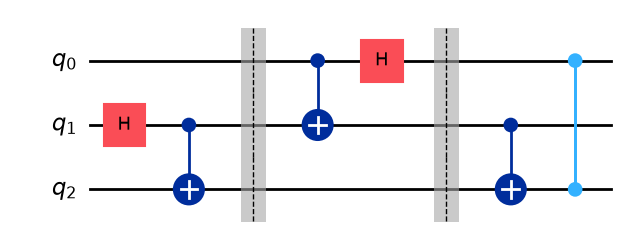

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator

simulator = AerSimulator()

protocol = QuantumCircuit(3)
# 1. Entangled channel between Alice (q1) and Bob (q2)
protocol.h(1)
protocol.cx(1, 2)
protocol.barrier()
# 2. Alice's interaction
protocol.cx(0, 1)
protocol.h(0)
protocol.barrier()
# 3-5. Corrections, written here as controlled gates (see section 3)
protocol.cx(1, 2)    # "if q1 == 1 apply X to q2"
protocol.cz(0, 2)    # "if q0 == 1 apply Z to q2"

print("Teleportation protocol (deferred-measurement form):")
protocol.draw('mpl')

### Lab: Teleportation Walkthrough

Before the code, watch the protocol happen. Set Alice's payload with the sliders, then press Next through the five stages. At each stage the three Bloch spheres
show who holds what, the text shows Alice's bits, and the fidelity line tells you how close Bob's qubit is to the payload.
Press Re-measure at stage 3 to see a different random outcome and a different twist for Bob to undo.

Teleportation Walkthrough (static preview of stage 3). Run this cell in JupyterLab for the interactive version.


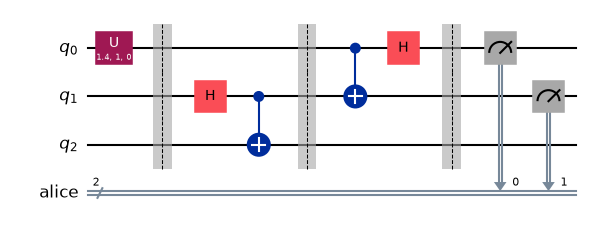

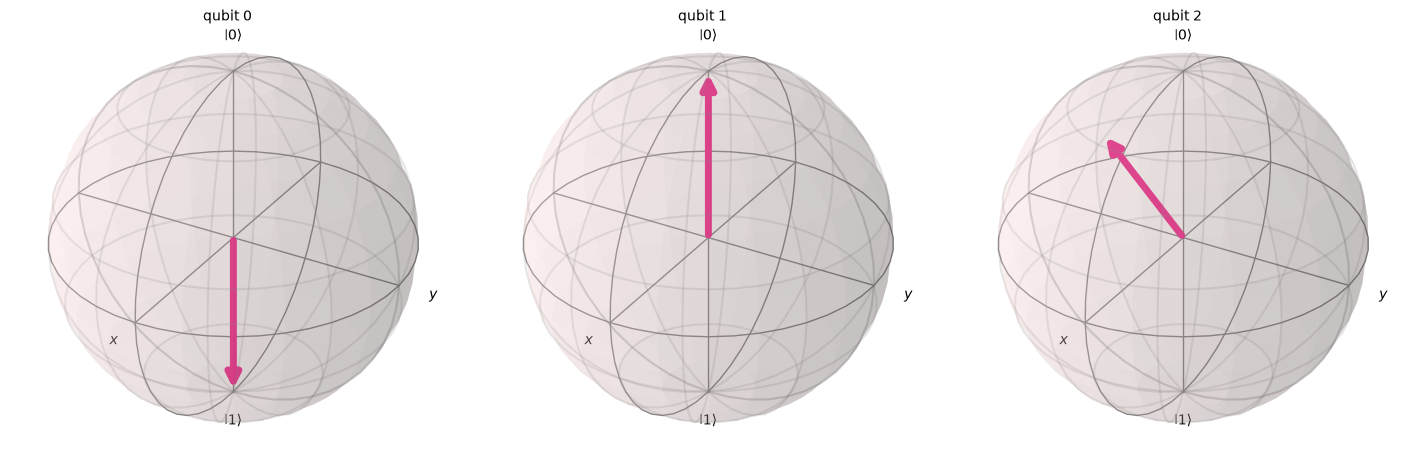

In [2]:
from qclab import teleport_walkthrough

teleport_walkthrough()

## 3. Version A: the unitary picture (deferred measurement)

The **principle of deferred measurement** says: a measurement followed by a classically controlled gate gives the same statistics as a
quantum-controlled gate followed by the measurement. So we can replace steps 3-5 with a CNOT and a CZ and keep everything as a `Statevector`.
That lets us look at Bob's qubit *exactly*, with no shots.

To check that Bob really has $|\psi\rangle$ we trace out Alice's two qubits and compute the **fidelity** between Bob's reduced state and the original.
Fidelity 1 means identical.

interactive(children=(FloatSlider(value=1.4, description='θ', max=3.141592653589793), FloatSlider(value=1.0, d…

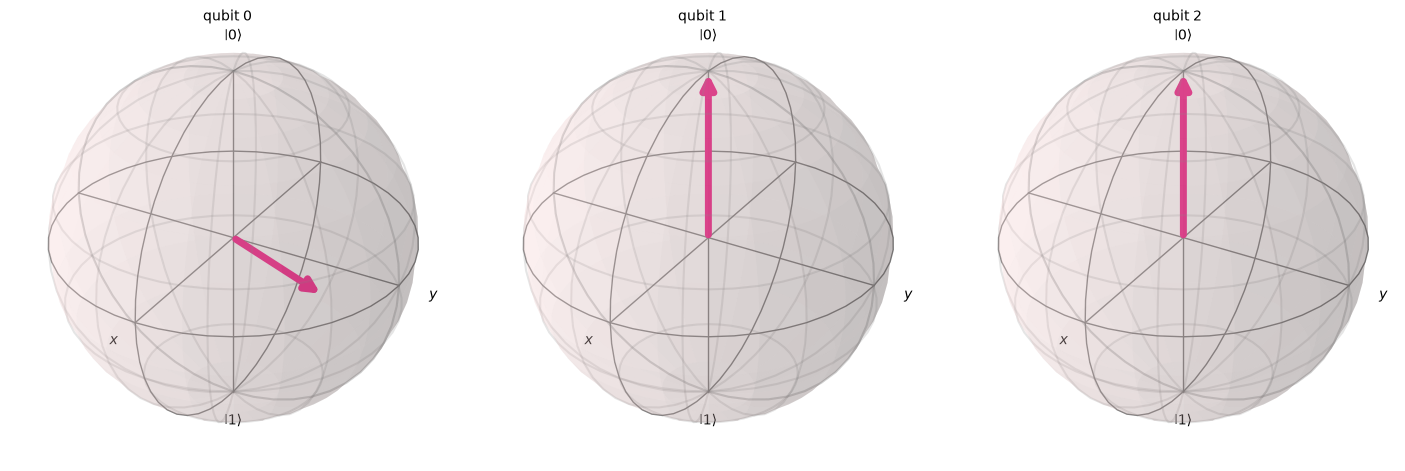

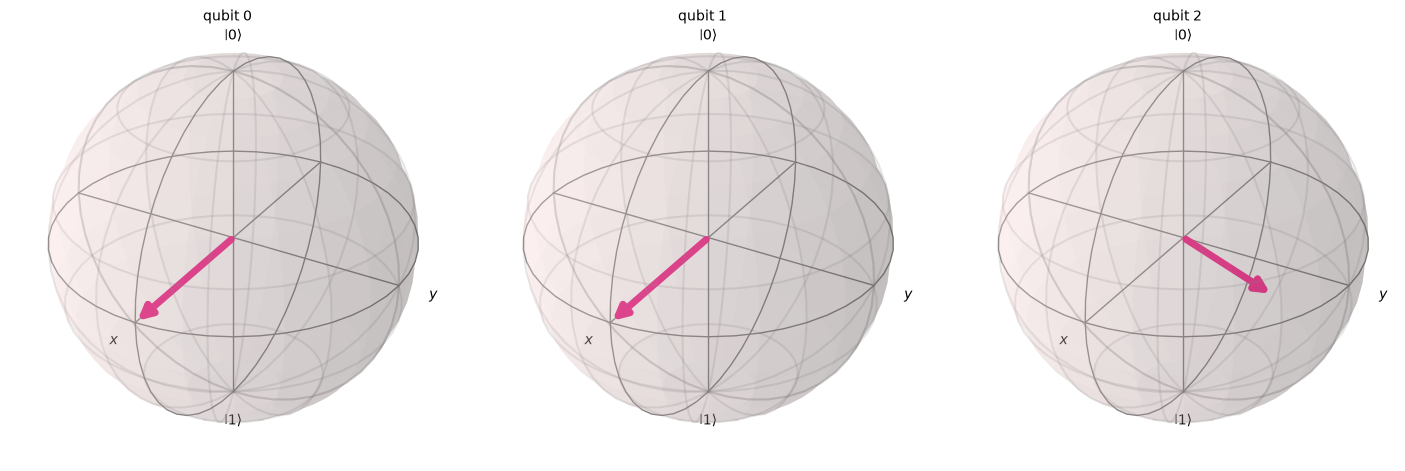

In [3]:
%matplotlib inline
from ipywidgets import interact, FloatSlider

def teleport_unitary(theta, phi):
    # Alice's payload: an arbitrary point on the Bloch sphere
    prep = QuantumCircuit(1)
    prep.u(theta, phi, 0, 0)
    psi = Statevector(prep)

    qc = QuantumCircuit(3)
    qc.compose(prep, [0], inplace=True)
    initial = Statevector(qc)
    qc.compose(protocol, inplace=True)
    final = Statevector(qc)

    bob = partial_trace(final, [0, 1])          # Bob's qubit alone
    F = state_fidelity(bob, psi)

    print(f"Payload: θ = {theta:.2f}, φ = {phi:.2f}")
    print("BEFORE: qubit 0 carries |ψ>, qubits 1 and 2 are the fresh |0> pair")
    display(plot_bloch_multivector(initial))
    print("AFTER:  qubit 2 now carries |ψ>. Qubits 0 and 1 are left maximally mixed (no arrow).")
    display(plot_bloch_multivector(final))
    print(f"Fidelity between Bob's qubit and the original |ψ>: {F:.4f}")

interact(teleport_unitary,
         theta=FloatSlider(min=0, max=np.pi, step=0.1, value=1.4, description='θ'),
         phi=FloatSlider(min=0, max=2*np.pi, step=0.1, value=1.0, description='φ'));

> **What to notice.** The arrow that was on qubit 0 reappears on qubit 2, at the same angles. Qubit 0's arrow has vanished: the original is destroyed,
> exactly as no-cloning demands. The fidelity stays 1.0000 for every setting of the sliders.

## 4. Version B: the real protocol with measurement and feed-forward

Now do it properly: Alice measures, and Bob's corrections are **classically conditioned** on her bits using `if_test`.
This is what runs on real hardware.

Since Bob's qubit is measured at the end, we cannot compare Bloch spheres. Instead we use the standard verification trick:
apply the **inverse** of Alice's preparation to Bob's qubit. If Bob holds $|\psi\rangle$, undoing the preparation returns $|0\rangle$ and his measurement
reads $0$ every single time. If teleportation failed, some shots will read $1$.

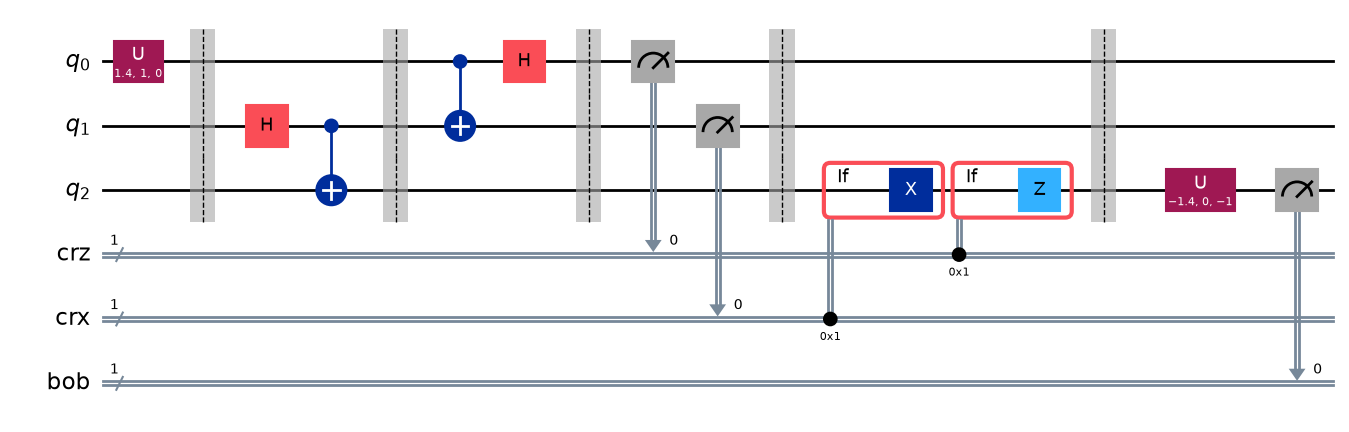

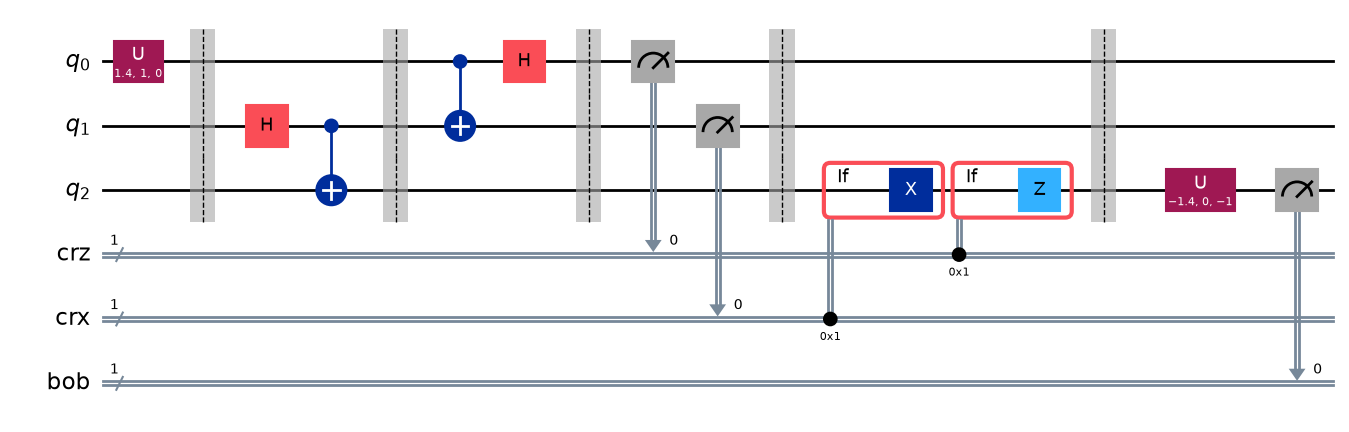

In [4]:
def teleport_circuit(prep, correct=True):
    q   = QuantumRegister(3, 'q')
    crz = ClassicalRegister(1, 'crz')     # Alice's bit from q0 -> controls Z
    crx = ClassicalRegister(1, 'crx')     # Alice's bit from q1 -> controls X
    bob = ClassicalRegister(1, 'bob')     # Bob's verification bit
    qc = QuantumCircuit(q, crz, crx, bob)

    qc.compose(prep, [0], inplace=True)   # Alice's payload
    qc.barrier()
    qc.h(1); qc.cx(1, 2)                  # 1. entangled channel
    qc.barrier()
    qc.cx(0, 1); qc.h(0)                  # 2. Alice's interaction
    qc.barrier()
    qc.measure(0, crz); qc.measure(1, crx)   # 3. Alice measures
    qc.barrier()
    if correct:                           # 4-5. Bob's classically controlled corrections
        with qc.if_test((crx, 1)):
            qc.x(2)
        with qc.if_test((crz, 1)):
            qc.z(2)
    qc.barrier()
    qc.compose(prep.inverse(), [2], inplace=True)   # verification: undo the preparation
    qc.measure(2, bob)
    return qc

prep = QuantumCircuit(1)
prep.u(1.4, 1.0, 0, 0)
qc = teleport_circuit(prep)
qc.draw('mpl')

Full results (bob crx crz): {'0 0 1': 255, '0 0 0': 236, '0 1 0': 238, '0 1 1': 271}

Alice's bits are random, but Bob's verification bit is 0 in every branch:
  Alice sent (crz=0, crx=0)  ->  Bob measured 0   (236 shots)
  Alice sent (crz=1, crx=0)  ->  Bob measured 0   (255 shots)
  Alice sent (crz=0, crx=1)  ->  Bob measured 0   (238 shots)
  Alice sent (crz=1, crx=1)  ->  Bob measured 0   (271 shots)

Bob's bit alone: {'0': 1000}


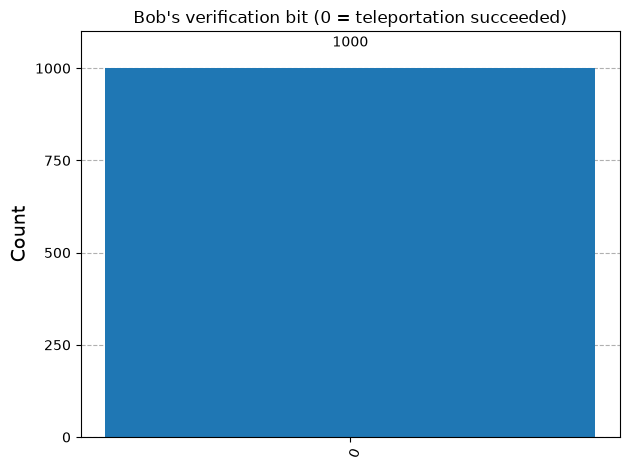

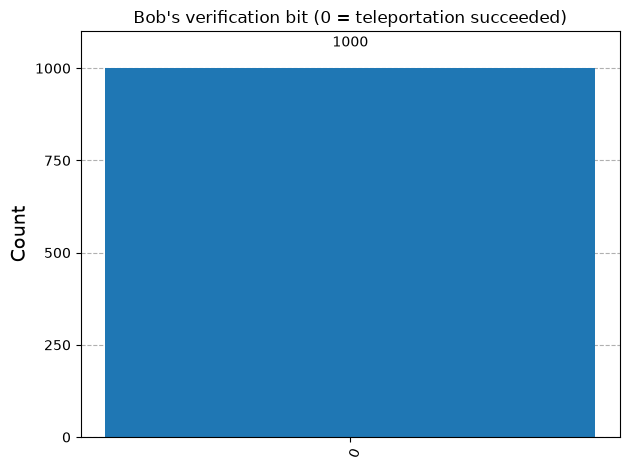

In [5]:
counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()

print("Full results (bob crx crz):", counts)
print()
print("Alice's bits are random, but Bob's verification bit is 0 in every branch:")
for key in sorted(counts):
    bob_bit, crx_bit, crz_bit = key.split()
    print(f"  Alice sent (crz={crz_bit}, crx={crx_bit})  ->  Bob measured {bob_bit}   ({counts[key]} shots)")

bob_only = marginal_counts(counts, indices=[2])
print("\nBob's bit alone:", bob_only)
plot_histogram(bob_only, title="Bob's verification bit (0 = teleportation succeeded)")

In [6]:
# Random payloads: does it work for every state?
rng = np.random.default_rng(7)
print("  θ      φ     success rate")
for _ in range(6):
    theta, phi = rng.uniform(0, np.pi), rng.uniform(0, 2*np.pi)
    prep = QuantumCircuit(1); prep.u(theta, phi, 0, 0)
    qc = teleport_circuit(prep)
    counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()
    success = marginal_counts(counts, indices=[2]).get('0', 0) / 1000
    print(f"{theta:5.2f}  {phi:5.2f}     {success:.1%}")

  θ      φ     success rate
 1.96   5.64     100.0%
 2.44   1.42     100.0%
 0.94   5.49     100.0%
 0.02   5.16     100.0%
 2.50   2.94     100.0%


 0.95   1.75     100.0%


## 5. What if Bob ignores Alice's bits?

Without the corrections, Bob's qubit is $|\psi\rangle$, $X|\psi\rangle$, $Z|\psi\rangle$ or $XZ|\psi\rangle$ with equal probability, and he has no idea which.
The verification measurement now fails in a large fraction of shots. The two classical bits are not an optional extra; they are the message.

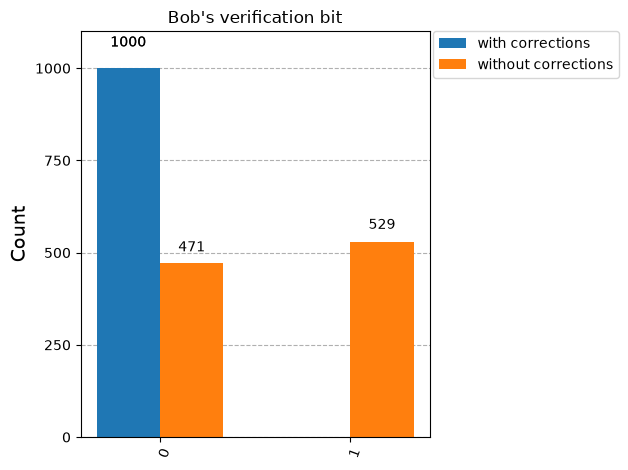

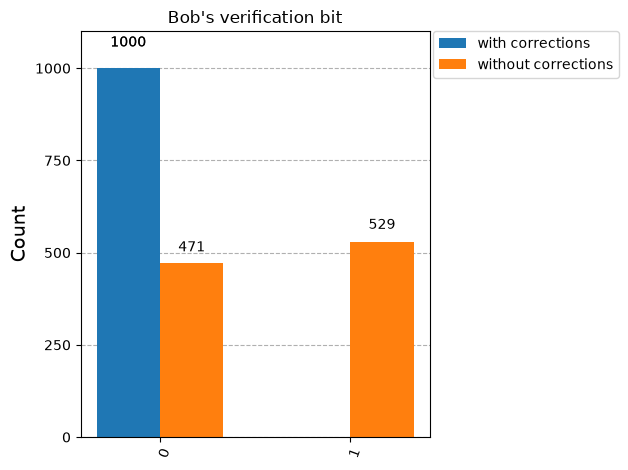

In [7]:
prep = QuantumCircuit(1); prep.u(1.4, 1.0, 0, 0)

results = {}
for label, correct in [("with corrections", True), ("without corrections", False)]:
    qc = teleport_circuit(prep, correct=correct)
    counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()
    results[label] = marginal_counts(counts, indices=[2])

plot_histogram(list(results.values()), legend=list(results.keys()), title="Bob's verification bit")

## 6. Discussion

* **No faster-than-light signalling.** Bob's qubit changes instantly when Alice measures, but into one of four random possibilities. Only the classical bits, which travel at light speed or slower, make it useful.
* **No cloning.** Alice's qubit is measured; her copy of $|\psi\rangle$ is gone. One copy in, one copy out.
* **Why it matters.** Teleportation is the basic operation of quantum networks (moving states between nodes) and of fault-tolerant computing
  (moving logical qubits and applying gates through "gate teleportation").
* **Superdense coding** is the mirror image: with one shared Bell pair, sending *one qubit* delivers *two classical bits*.

## Try it yourself

**Exercise 1.** Teleport $|+\rangle$, $|-\rangle$ and $|i\rangle$ with `teleport_circuit`. (Prepare them with H, H+Z, H+S.)

**Exercise 2.** In `teleport_circuit`, swap the two corrections (X conditioned on `crz`, Z on `crx`). What is the success rate now? Why is it not 0 %?

**Exercise 3.** Use Version A to compute the fidelity when Bob applies *only* the X correction. Average over the four measurement branches by hand or with `partial_trace`.

**Exercise 4 (challenge).** Implement superdense coding: Alice and Bob share $|\Phi^+\rangle$; Alice applies I, X, Z or XZ to her qubit to encode two bits, sends it to Bob; Bob applies CNOT and H and measures both qubits to recover the bits.

<details><summary>Solutions (1, 2, 4)</summary>

```python
# Exercise 1
for name, gates in [("|+>", ['h']), ("|->", ['h', 'z']), ("|i>", ['h', 's'])]:
    prep = QuantumCircuit(1)
    for g in gates: getattr(prep, g)(0)
    counts = simulator.run(transpile(teleport_circuit(prep), simulator), shots=1000).result().get_counts()
    print(name, marginal_counts(counts, indices=[2]))          # all {'0': 1000}

# Exercise 2: the wrong correction is applied in half the branches; success depends on the state, typically ~50-75 %.

# Exercise 4: superdense coding
def superdense(bits):
    qc = QuantumCircuit(2, 2)
    qc.h(0); qc.cx(0, 1)                 # shared Bell pair, Alice holds q0
    if bits[1] == '1': qc.x(0)           # encode
    if bits[0] == '1': qc.z(0)
    qc.cx(0, 1); qc.h(0)                 # Bob decodes (after receiving q0)
    qc.measure([0, 1], [0, 1])
    return simulator.run(qc, shots=100).result().get_counts()
for b in ['00', '01', '10', '11']:
    print(b, '->', superdense(b))        # each decodes to exactly b
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from qclab import quiz

quiz(5)

Checkpoint quiz, Module 5 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. How many classical bits must Alice send to Bob in teleportation?
    a) 0
    b) 1
    c) 2
    d) one per amplitude

Q2. After the protocol, Alice's original qubit is
    a) an unchanged copy
    b) entangled with Bob's qubit
    c) collapsed by her measurement
    d) in |+>

Q3. Why can teleportation not send information faster than light?
    a) the qubits are too slow
    b) Bob's qubit is useless until the classical bits arrive
    c) entanglement breaks over distance
    d) Alice must wait for Bob's reply

Q4. Alice's bit from qubit 1 (the CNOT target) is 1. Bob applies
    a) X
    b) Z
    c) H
    d) nothing


## Key takeaways

* No-cloning: quantum states cannot be copied, so they must be *moved*.
* Teleportation = one Bell pair + Alice's Bell measurement + two classical bits + Bob's X/Z corrections.
* Deferred measurement lets you analyse the protocol as a unitary and check fidelity exactly; `if_test` lets you run the real, classically conditioned version.
* Verification trick: undo the preparation on the receiving end and check for $|0\rangle$.

**Next:** the first algorithm where a quantum computer provably beats a classical one. [Module 6](06_Deutsch_Jozsa_Algorithm.ipynb).

[Previous: Module 4: Measurement & Interference](04_Measurement_and_Interference.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 6: Deutsch-Jozsa, the First Quantum Speed-up](06_Deutsch_Jozsa_Algorithm.ipynb)